In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

import cv2
from google.colab import drive


In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
audio_folder = '/content/drive/MyDrive/colombian_ birds_audio'

audio_files = os.listdir(audio_folder)
print(f"Se encontraron {len(audio_files)} archivos")
print(audio_files[:10])  # ver los primeros 10

Se encontraron 1101 archivos
['Basileuterus_delattrii_562169 (9).mp3', 'Basileuterus_delattrii_562165 (9).mp3', 'Basileuterus_delattrii_560765 (9).mp3', 'Basileuterus_delattrii_552747 (9).mp3', 'Saltator_olivascens_542031 (9).mp3', 'Basileuterus_delattrii_540091 (9).mp3', 'Saltator_olivascens_525017 (9).mp3', 'Saltator_olivascens_525016 (9).mp3', 'Saltator_olivascens_525015 (9).mp3', 'Saltator_olivascens_525014 (9).mp3']


In [4]:
def audio_to_mel_chunks(path, segment_duration=5, n_mels=128):
    import librosa
    import numpy as np

    y, sr = librosa.load(path, sr=None)
    if len(y) == 0:
        return [], sr

    segment_length = int(sr * segment_duration)
    total_length = len(y)
    mels = []

    for start in range(0, total_length, segment_length):
        end = start + segment_length
        segment = y[start:end]

        # padding si es más corto
        if len(segment) < segment_length:
            segment = np.pad(segment, (0, segment_length - len(segment)))

        mel = librosa.feature.melspectrogram(y=segment, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        mels.append(mel_db)

    # si el audio era más corto que 1 chunk
    if len(mels) == 0 and len(y) > 0:
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mels.append(mel_db)

    return mels, sr

In [5]:
def pad_to_224(mel, target_size=(224, 224)):
    h, w = mel.shape

    # 1. escalar SOLO altura (128 → 224)
    scale = target_size[0] / h
    new_w = int(w * scale)

    mel_resized = cv2.resize(mel, (new_w, target_size[0]))

    # 2. crear canvas vacío (ceros)
    output = np.zeros(target_size)

    # 3. meter el espectrograma
    if new_w <= target_size[1]:
        output[:, :new_w] = mel_resized
    else:
        # si se pasa → recorte
        output = mel_resized[:, :target_size[1]]

    return output

In [6]:
def process_audio(path):
    mel_chunks = audio_to_mel_chunks(path)
    processed = []

    for mel in mel_chunks:
        mel = pad_to_224(mel)  # la función que ya hicimos

        # normalizar
        mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-6)

        # 3 canales
        mel = np.stack([mel]*3, axis=-1)

        processed.append(mel)

    return processed

In [ ]:
X, y = [], []
problemas = []

for i, file in enumerate(audio_files):
    print(f"[{i+1}/{len(audio_files)}] {file}", flush=True)  # progreso
    
    file_path = f"{audio_folder}/{file}"
    label = "_".join(file.split("_")[:-1])

    try:
        mel_chunks, sr = audio_to_mel_chunks(file_path)
        
        if not mel_chunks:
            print(f"  → Sin chunks", flush=True)
            continue

        processed = []
        for mel in mel_chunks:
            mel = pad_to_224(mel)
            mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-6)
            mel = np.stack([mel] * 3, axis=-1)
            processed.append(mel)

        if not processed:
            print(f"  → Sin processed", flush=True)
            continue

        energies = [np.std(m) for m in processed]
        top_idx = np.argsort(energies)[-1]

        X.append(processed[top_idx])
        y.append(label)
        print(f"  → OK", flush=True)

    except Exception as e:
        problemas.append((file, str(e)))
        print(f"  → ERROR: {e}", flush=True)
        continue

print(f"\nProcesados OK: {len(X)}")
print(f"Con error: {len(problemas)}")

X = np.array(X, dtype=np.float32)
print(X.shape, y.shape)

[1/1101] Basileuterus_delattrii_562169 (9).mp3
  → OK
[2/1101] Basileuterus_delattrii_562165 (9).mp3
  → OK
[3/1101] Basileuterus_delattrii_560765 (9).mp3
  → OK
[4/1101] Basileuterus_delattrii_552747 (9).mp3
  → OK
[5/1101] Saltator_olivascens_542031 (9).mp3
  → OK
[6/1101] Basileuterus_delattrii_540091 (9).mp3
  → OK
[7/1101] Saltator_olivascens_525017 (9).mp3
  → OK
[8/1101] Saltator_olivascens_525016 (9).mp3
  → OK
[9/1101] Saltator_olivascens_525015 (9).mp3
  → OK
[10/1101] Saltator_olivascens_525014 (9).mp3
  → OK
[11/1101] Saltator_olivascens_502836 (9).mp3
  → OK
[12/1101] Basileuterus_delattrii_492567 (9).mp3
  → OK
[13/1101] Basileuterus_delattrii_428318 (9).mp3
  → OK
[14/1101] Scinax_caprarius_1092340 (9).mp3
  → OK
[15/1101] Boana_pugnax_1092293 (9).mp3
  → OK
[16/1101] Dendropsophus_molitor_1092277 (9).mp3
  → OK
[17/1101] Scinax_kennedyi_1092263 (9).mp3
  → OK
[18/1101] Boana_rosenbergi_1092114 (9).mp3
  → OK
[19/1101] Dendropsophus_norandinus_1090676 (9).mp3
  → OK
[20/

In [24]:
labels = np.unique(y)
class_labers = {label: idx for idx, label in enumerate(labels)}

In [ ]:
def encode_label(label_str, class_labers):
    label_vector = np.zeros(len(class_labers))

    species = label_str

    if species in class_labers:
            label_vector[class_labers[species]] = 1

    return label_vector

In [ ]:
y = np.array([encode_label(label, class_labers) for label in y])

In [39]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

num_classes = len(labels)
y_idx = y.argmax(axis=1)  # convertir etiquetas a índices
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_idx
)

# ── 3. Dataset ────────────────────────────────────────────────────
class BirdDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
        self.y = torch.tensor(y.argmax(axis=1), dtype=torch.long)  # one-hot → índice
    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = BirdDataset(X_train, y_train)
val_ds   = BirdDataset(X_val,   y_val)

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=16, shuffle=False)

# ── 4. Modelo CNN + LSTM ──────────────────────────────────────────
class BirdCNNLSTM(nn.Module):
    def __init__(self, num_classes, hidden_size=128, num_layers=2):
        super().__init__()

        # CNN: extrae features por "franjas" verticales del espectrograma
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # → (32, 112, 112)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # → (64, 56, 56)
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # → (128, 28, 28)
        )

        # Cada columna del feature map = 1 paso temporal para la LSTM
        # input_size = 128 * 28 (canales × altura)
        self.lstm = nn.LSTM(
            input_size=128 * 28,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (B, 3, 224, 224)
        features = self.cnn(x)                        # (B, 128, 28, 28)
        B, C, H, W = features.shape
        # reorganizar: cada columna W es un timestep
        seq = features.permute(0, 3, 1, 2)            # (B, W, C, H)
        seq = seq.reshape(B, W, C * H)                # (B, 28, 128*28)
        _, (hidden, _) = self.lstm(seq)               # hidden: (layers, B, hidden)
        out = self.classifier(hidden[-1])             # última capa → (B, num_classes)
        return out

# ── 5. Entrenamiento ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

model     = BirdCNNLSTM(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def train_epoch(model, dl, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (pred.argmax(1) == yb).sum().item()
    return total_loss / len(dl), correct / len(dl.dataset)

def eval_epoch(model, dl, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            total_loss += criterion(pred, yb).item()
            correct += (pred.argmax(1) == yb).sum().item()
    return total_loss / len(dl), correct / len(dl.dataset)

# ── 6. Loop principal ─────────────────────────────────────────────
EPOCHS = 40
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_dl, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model, val_dl, criterion)
    scheduler.step()

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.3f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.3f}")

    # guardar mejor modelo
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_bird_model.pt")
        print(f"  ✓ Modelo guardado (val_acc: {val_acc:.3f})")

print(f"\nMejor val_acc: {best_val_acc:.3f}")

Usando: cpu
Epoch 01/40 | Train loss: 3.0687 acc: 0.148 | Val loss: 2.8189 acc: 0.181
  ✓ Modelo guardado (val_acc: 0.181)
Epoch 02/40 | Train loss: 2.9193 acc: 0.139 | Val loss: 2.8497 acc: 0.181
Epoch 03/40 | Train loss: 2.9089 acc: 0.145 | Val loss: 2.8077 acc: 0.181
Epoch 04/40 | Train loss: 2.8699 acc: 0.160 | Val loss: 2.8007 acc: 0.181
Epoch 05/40 | Train loss: 2.8463 acc: 0.170 | Val loss: 2.7940 acc: 0.181
Epoch 06/40 | Train loss: 2.8012 acc: 0.183 | Val loss: 2.6547 acc: 0.181
Epoch 07/40 | Train loss: 2.6623 acc: 0.181 | Val loss: 2.5542 acc: 0.190
  ✓ Modelo guardado (val_acc: 0.190)
Epoch 08/40 | Train loss: 2.4768 acc: 0.200 | Val loss: 2.2754 acc: 0.317
  ✓ Modelo guardado (val_acc: 0.317)
Epoch 09/40 | Train loss: 2.3421 acc: 0.227 | Val loss: 2.0860 acc: 0.290
Epoch 10/40 | Train loss: 2.1545 acc: 0.268 | Val loss: 1.8981 acc: 0.339
  ✓ Modelo guardado (val_acc: 0.339)
Epoch 11/40 | Train loss: 1.9201 acc: 0.351 | Val loss: 1.6870 acc: 0.489
  ✓ Modelo guardado (val_a

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00        40
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         2
           5       1.00      0.40      0.57         5
           6       0.00      0.00      0.00         2
           7       1.00      1.00      1.00         2
           8       1.00      0.60      0.75         5
           9       1.00      1.00      1.00         7
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2
          13       0.92      1.00      0.96        24
          14       1.00      1.00      1.00         5
          15       0.90      1.00      0.95        18
          16       0.45      1.00      0.62         5
          17       0.00    

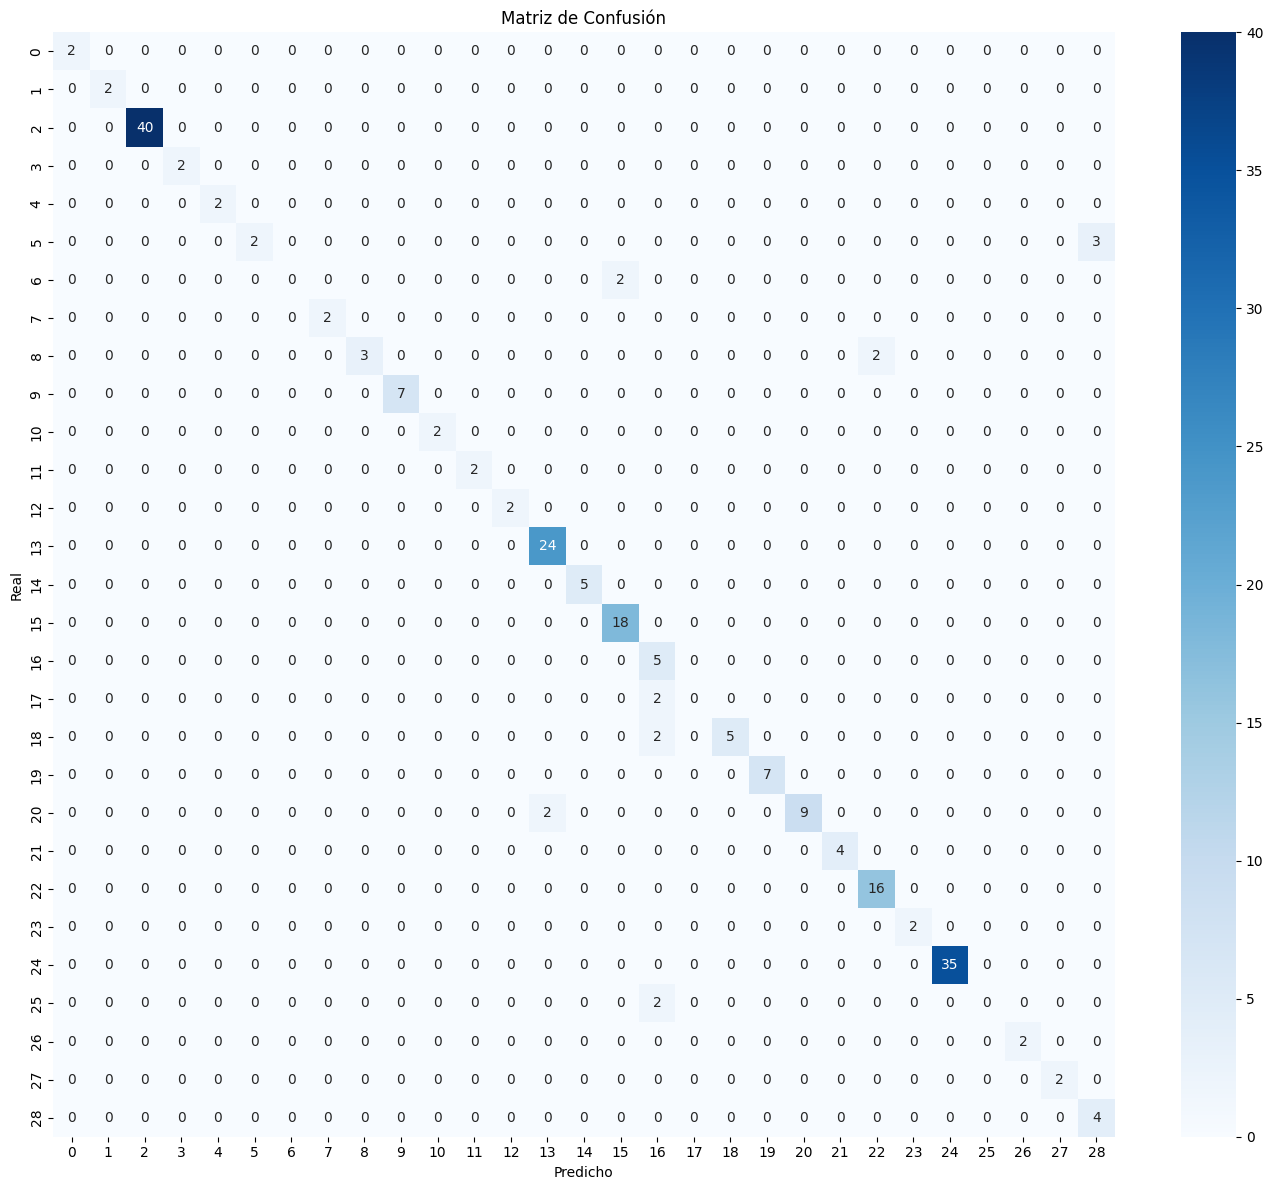

In [40]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Predicciones ───────────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in val_dl:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        all_preds.extend(pred.argmax(1).cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── 2. Reporte por clase ──────────────────────────────────────────
print(classification_report(all_labels, all_preds))

# ── 3. Matriz de confusión ────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()